# V4: Precision–Recall 容错代价实验（5 条曲线 + 分图）

目标：用 PR 曲线展示各方法在提升容错时牺牲了多少 precision；**每条曲线只调一个参数**，其余固定默认值。
- **5 条曲线**：Tensor Sketch (top_k)、Strobemer (k)、Strobemer (w_min)、Spaced Seed (weight)、Spaced Seed (similarity)
- **主图**：5 条曲线同图对比；**分图**：每个方法一张（Tensor Sketch / Strobemer / Spaced Seed）
- Recall：position-level recall；Precision：hit-level precision（无命中记为 1.0）
- 画图数据保存为 `pr_plot_data.json`，便于复现。

In [1]:
%matplotlib inline
import os
import sys
import random
import tempfile
import subprocess
import csv
import json
import time
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
import numpy as np

_nb_dir = Path.cwd()
if (_nb_dir / "v4_precision_recall_tradeoff.ipynb").exists():
    METHODS_DIR = _nb_dir
elif (_nb_dir / "methods" / "v4_precision_recall_tradeoff.ipynb").exists():
    METHODS_DIR = _nb_dir / "methods"
else:
    METHODS_DIR = _nb_dir
PROJECT_DIR = METHODS_DIR.parent
OUTPUT_DIR = METHODS_DIR / "v4_benchmark_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("METHODS_DIR:", METHODS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

METHODS_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods
OUTPUT_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods/v4_benchmark_output


In [2]:
# ── Data generation (reused from v3) ──
def load_reference(fasta_path, max_len=10000):
    seq_parts = []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith(">"):
                continue
            seq_parts.append(line.strip().upper())
    return "".join(seq_parts)[:max_len]

def mutate_sequence(sequence, mutation_rate, rng):
    bases = ['A', 'T', 'C', 'G']
    seq_list = list(sequence)
    length = len(seq_list)
    num_mutations = max(1, int(length * mutation_rate))
    for _ in range(num_mutations):
        idx = rng.randint(0, len(seq_list) - 1)
        op = rng.choice(['sub', 'del', 'ins'])
        if op == 'sub':
            original = seq_list[idx]
            choices = [b for b in bases if b != original]
            if choices:
                seq_list[idx] = rng.choice(choices)
        elif op == 'del' and len(seq_list) > length // 2:
            del seq_list[idx]
        elif op == 'ins':
            seq_list.insert(idx, rng.choice(bases))
    return ''.join(seq_list)

def generate_test_data(reference, mutation_rate, num_reads, read_length, seed=42):
    rng = random.Random(seed)
    reads = []
    ref_len = len(reference)
    for i in range(num_reads):
        start = rng.randint(0, max(0, ref_len - read_length))
        fragment = reference[start:start + read_length]
        if len(fragment) < read_length:
            continue
        mutated = mutate_sequence(fragment, mutation_rate, rng)
        reads.append((f"read_{i:04d}", mutated, start, fragment))
    return reads

def _simple_edit_dist(a, b):
    la, lb = len(a), len(b)
    if abs(la - lb) > max(la, lb) // 2:
        return max(la, lb)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a):
        curr = [i + 1] + [0] * lb
        for j, cb in enumerate(b):
            curr[j + 1] = min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (0 if ca == cb else 1))
        prev = curr
    return prev[lb]

def find_true_positions(reference, query_seq, edit_tolerance, window_size=None):
    ws = window_size if window_size is not None else len(query_seq)
    positions = []
    for s in range(len(reference) - ws + 1):
        if _simple_edit_dist(reference[s:s + ws], query_seq) <= edit_tolerance:
            positions.append(s)
    return positions

def _build_true_set_worker(args):
    rid, mutated_seq, reference, edit_tolerance, window_size = args
    return rid, frozenset(find_true_positions(reference, mutated_seq, edit_tolerance, window_size=window_size))

def build_true_sets(reads, reference, edit_tolerance, window_size=None):
    tasks = [(r[0], r[1], reference, edit_tolerance, window_size) for r in reads]
    result = {}
    with ProcessPoolExecutor() as pool:
        for rid, positions in pool.map(_build_true_set_worker, tasks):
            result[rid] = positions
    return result

def write_fasta(path, name, seq):
    with open(path, 'w') as f:
        f.write(f">{name}\n{seq}\n")

def write_fastq(path, reads):
    with open(path, 'w') as f:
        for r in reads:
            f.write(f"@{r[0]}\n{r[1]}\n+\n{'I' * len(r[1])}\n")

In [3]:
# ── Method runners (strobemer, spaced_seed, tensor_sketch only) ──
def run_strobemer(ref_fa, query_fq, out_tsv, params):
    strobe_dir = METHODS_DIR / "ksahlin" / "strobemers"
    cmd = [sys.executable, str(strobe_dir / "StrobeMap"), "--queries", query_fq, "--references", ref_fa,
           "--outfolder", str(Path(out_tsv).parent), "--prefix", Path(out_tsv).stem, "--k", str(params.get("k", 15)),
           "--strobe_w_min_offset", str(params.get("w_min", 20)), "--strobe_w_max_offset", str(params.get("w_max", 70)),
           "--w", str(params.get("w", 1)), "--n", str(params.get("order", 2)), "--rev_comp"]
    env = os.environ.copy()
    env["PYTHONPATH"] = str(strobe_dir) + os.pathsep + env.get("PYTHONPATH", "")
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, env=env, cwd=str(strobe_dir))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    raw = Path(out_tsv).parent / (Path(out_tsv).stem + ".tsv")
    hits = parse_strobemer_output(str(raw))
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_strobemer_output(raw_path):
    results = defaultdict(list)
    if not os.path.exists(raw_path):
        return results
    current_query = None
    with open(raw_path) as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                parts = line[2:].strip().split()
                current_query = parts[0] if parts else None
            else:
                fields = line.strip().split()
                if len(fields) >= 4 and current_query:
                    ref_pos = int(fields[1])
                    query_pos = int(fields[2])
                    inferred_start = ref_pos - query_pos
                    results[current_query].append({"ref_pos": inferred_start, "ref_start": inferred_start})
    return results

def run_spaced_seed(ref_fa, query_fq, out_tsv, params):
    ss_dir = METHODS_DIR / "spaced_seed"
    cmd = [sys.executable, str(ss_dir / "ales_fasta_fastq_align_parallel.py"), "--fasta", ref_fa, "--fastq", query_fq,
           "--output", out_tsv, "--weight", str(params.get("weight", 11)), "--homology-length", str(params.get("homology_length", 64)),
           "--similarity", str(params.get("similarity", 0.8)), "--k-seeds", str(params.get("k_seeds", 1)), "--no-revcomp", "--workers", "96"]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ss_dir))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    hits = parse_spaced_seed_output(out_tsv)
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_spaced_seed_output(tsv_path):
    results = defaultdict(list)
    if not os.path.exists(tsv_path):
        return results
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("read_id", "")
            if rid and rid != "*":
                ref_start = int(row.get("reference_start", 0))
                results[rid].append({"ref_start": ref_start, "ref_pos": ref_start})
    return results

def run_tensor_sketch(ref_fa, query_fq, out_tsv, params):
    binary = METHODS_DIR / "tensor-sketch-alignment" / "metagraph" / "mgsketch_index"
    if not binary.exists():
        return {"error": "mgsketch_index not found", "hits": defaultdict(list), "candidates_count": 0, "runtime": 0}
    cmd = [str(binary), "--ref_fasta", ref_fa, "--query_fastq", query_fq, "--output_tsv", out_tsv,
           "--window_size", str(params.get("window_size", 150)), "--stride", str(params.get("stride", 1)),
           "--hnsw_ef_search", str(params.get("hnsw_ef_search", 50)), "--top_k", str(params.get("top_k", 5)),
           "--sketch_dim", str(params.get("sketch_dim", 128)), "--tuple_size", str(params.get("tuple_size", 3))]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    hits = parse_tensor_sketch_output(out_tsv)
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_tensor_sketch_output(tsv_path):
    results = defaultdict(list)
    if not os.path.exists(tsv_path):
        return results
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("read_id", "")
            if rid:
                ref_start = int(row.get("reference_start", 0))
                results[rid].append({"ref_start": ref_start, "ref_pos": ref_start})
    return results

In [4]:
# ── PR metrics: position recall + hit-level precision ──
POS_TOLERANCE = 5

def position_recall(match_results, reads, reference, edit_tolerance, pos_tolerance=POS_TOLERANCE,
                    precomputed_true_sets=None, window_size=None):
    """Fraction of true mapping positions covered by at least one hit (micro-average)."""
    if isinstance(match_results, dict) and "error" in match_results:
        return 0.0
    hits_dict = match_results.get("hits", match_results) if isinstance(match_results, dict) else match_results
    total_true = 0
    total_found = 0
    for r in reads:
        rid = r[0]
        if precomputed_true_sets is not None:
            true_positions = precomputed_true_sets.get(rid, frozenset())
        else:
            true_positions = frozenset(find_true_positions(reference, r[1], edit_tolerance, window_size=window_size))
        if not true_positions:
            continue
        reported = [m.get("ref_pos", m.get("ref_start", -1)) for m in hits_dict.get(rid, [])]
        for tp in true_positions:
            if any(abs(rp - tp) <= pos_tolerance for rp in reported):
                total_found += 1
        total_true += len(true_positions)
    return total_found / total_true if total_true > 0 else 0.0

def compute_hit_precision(match_results, reads, precomputed_true_sets, pos_tolerance=POS_TOLERANCE):
    """Hit-level precision: each reported hit is TP if within pos_tolerance of any true position for that read, else FP.
    precision = TP / (TP + FP). If no hits at all, return 1.0 and no_hit_reads count."""
    if isinstance(match_results, dict) and "error" in match_results:
        return 0.0, 0
    hits_dict = match_results.get("hits", match_results) if isinstance(match_results, dict) else match_results
    tp = 0
    fp = 0
    no_hit_reads = 0
    for r in reads:
        rid = r[0]
        true_set = precomputed_true_sets.get(rid)
        if true_set is None:
            true_set = frozenset()
        hit_list = hits_dict.get(rid, [])
        if not hit_list:
            no_hit_reads += 1
            continue
        for m in hit_list:
            ref_pos = m.get("ref_pos", m.get("ref_start", -1))
            if ref_pos < 0:
                continue
            if any(abs(ref_pos - tp_val) <= pos_tolerance for tp_val in true_set):
                tp += 1
            else:
                fp += 1
    total = tp + fp
    if total == 0:
        return 1.0, no_hit_reads
    return tp / total, no_hit_reads

def evaluate_pr_point(match_results, reads, reference, edit_tolerance, precomputed_true_sets,
                      window_size=None, pos_tolerance=POS_TOLERANCE):
    """Returns (precision, recall, candidates_count, no_hit_reads)."""
    rec = position_recall(match_results, reads, reference, edit_tolerance,
                          pos_tolerance=pos_tolerance, precomputed_true_sets=precomputed_true_sets,
                          window_size=window_size)
    prec, no_hit = compute_hit_precision(match_results, reads, precomputed_true_sets, pos_tolerance=pos_tolerance)
    cand = match_results.get("candidates_count", 0) if isinstance(match_results, dict) else 0
    return prec, rec, cand, no_hit

## 参数扫描：5 条曲线（每条只调一个参数，其余固定默认值）
- **tensor_sketch**: 只调 `top_k`。
- **strobemer**: 两条曲线——只调 `k`、只调 `w_min`（`w_max` 由与 k 的约束得到）。
- **spaced_seed**: 两条曲线——只调 `weight`、只调 `similarity`（`weight < homology_length`）。

In [5]:
# Constraint: strobemer w_max vs k
def resolve_strobemer_wmax(k, w_min, beta=0.4):
    w_max = min(k - 1, w_min + max(1, round(beta * k)))
    if w_max <= w_min:
        w_max = min(k - 1, w_min + 1)
    if w_max <= w_min or k < 2:
        return None, False
    return int(w_max), True

def tensor_sketch_top_k_curve(hnsw_ef_search=500, window_size=100, tuple_size=3, sketch_dim=64):
    for top_k in [1, 2, 5, 10, 20, 50, 100, 200, 500]:
        yield {"hnsw_ef_search": hnsw_ef_search, "top_k": top_k, "window_size": window_size, "tuple_size": tuple_size, "sketch_dim": sketch_dim}

def strobemer_k_curve(w_min_default=2, order=2, k_values=None):
    k_values = k_values or [30, 25, 20, 15, 12, 10, 8, 6, 5, 4, 3]
    for k in k_values:
        w_max, ok = resolve_strobemer_wmax(k, w_min_default)
        if not ok:
            continue
        yield {"k": k, "order": order, "w_min": w_min_default, "w_max": w_max}

def strobemer_wmin_curve(k_default=15, order=2, w_min_values=None):
    w_min_values = w_min_values or [2, 3, 4, 5, 6, 8, 10]
    for w_min in w_min_values:
        w_max, ok = resolve_strobemer_wmax(k_default, w_min)
        if not ok:
            continue
        yield {"k": k_default, "order": order, "w_min": w_min, "w_max": w_max}

# Spaced Seed 两条独立曲线：一条只调 weight，一条只调 similarity
def spaced_weight_curve(homology_length=80, k_seeds=1, similarity_fixed=0.8, weight_values=None):
    weight_values = weight_values or [5, 9, 12, 15, 20, 23, 28, 30]
    for w in weight_values:
        if w >= homology_length:
            continue
        yield {"weight": w, "similarity": similarity_fixed, "homology_length": homology_length, "k_seeds": k_seeds}

def spaced_similarity_curve(homology_length=80, k_seeds=1, weight_fixed=20, similarity_values=None):
    similarity_values = similarity_values or [0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    for sim in similarity_values:
        yield {"weight": weight_fixed, "similarity": sim, "homology_length": homology_length, "k_seeds": k_seeds}

METHOD_RUNNERS = {"tensor_sketch": run_tensor_sketch, "strobemer": run_strobemer, "spaced_seed": run_spaced_seed}

CURVE_SPECS = [
    {"curve_id": "ts_top_k", "method": "tensor_sketch", "label": "Tensor Sketch (top_k)", "varied_param": "top_k", "params_list": list(tensor_sketch_top_k_curve()), "fixed_defaults": {"hnsw_ef_search": 500, "window_size": 100, "tuple_size": 3, "sketch_dim": 64}},
    {"curve_id": "strobemer_k", "method": "strobemer", "label": "Strobemer (k)", "varied_param": "k", "params_list": list(strobemer_k_curve()), "fixed_defaults": {"order": 2, "w_min": 2}},
    {"curve_id": "strobemer_w_min", "method": "strobemer", "label": "Strobemer (w_min)", "varied_param": "w_min", "params_list": list(strobemer_wmin_curve()), "fixed_defaults": {"order": 2, "k": 15}},
    {"curve_id": "spaced_weight", "method": "spaced_seed", "label": "Spaced Seed (weight)", "varied_param": "weight", "params_list": list(spaced_weight_curve()), "fixed_defaults": {"homology_length": 80, "k_seeds": 1, "similarity": 0.8}},
    {"curve_id": "spaced_similarity", "method": "spaced_seed", "label": "Spaced Seed (similarity)", "varied_param": "similarity", "params_list": list(spaced_similarity_curve()), "fixed_defaults": {"homology_length": 80, "k_seeds": 1, "weight": 20}},
]

In [6]:
# ── Config & data ──
REF_LENGTH = 2000
READ_LENGTH = 100
NUM_READS = 100
MUTATION_RATE = 0.05
EDIT_TOLERANCE = 15

ecoli_fa = str(PROJECT_DIR / "data" / "ecoli" / "fasta" / "ecoli.fa")
if not os.path.exists(ecoli_fa):
    raise FileNotFoundError(f"Reference not found: {ecoli_fa}")

reference = load_reference(ecoli_fa, max_len=REF_LENGTH)
reads = generate_test_data(reference, MUTATION_RATE, NUM_READS, READ_LENGTH, seed=42)
true_sets = build_true_sets(reads, reference, EDIT_TOLERANCE, window_size=READ_LENGTH)
print(f"Reads: {len(reads)}, Ref length: {len(reference)}")

Reads: 100, Ref length: 2000


In [7]:
# ── Run all curves (5 条), collect PR points ──
curve_series = {}
with tempfile.TemporaryDirectory() as tmpdir:
    ref_fa = os.path.join(tmpdir, "ref.fa")
    query_fq = os.path.join(tmpdir, "query.fq")
    write_fasta(ref_fa, "ref", reference)
    write_fastq(query_fq, reads)
    for spec in CURVE_SPECS:
        curve_id, method = spec["curve_id"], spec["method"]
        params_list = spec["params_list"]
        curve_series[curve_id] = []
        print(f"Running {curve_id} ({len(params_list)} params)")
        for idx, params in enumerate(params_list):
            out_tsv = os.path.join(tmpdir, f"{curve_id}_{idx}.tsv")
            res = METHOD_RUNNERS[method](ref_fa, query_fq, out_tsv, params)
            prec, rec, cand, no_hit = evaluate_pr_point(res, reads, reference, EDIT_TOLERANCE, true_sets, window_size=READ_LENGTH)
            curve_series[curve_id].append({"precision": prec, "recall": rec, "candidates_count": cand, "no_hit_reads": no_hit, "params": params})
for cid in curve_series:
    curve_series[cid] = sorted(curve_series[cid], key=lambda x: x["recall"])

Running ts_top_k (9 params)


Running strobemer_k (10 params)
Running strobemer_w_min (7 params)
Running spaced_weight (8 params)
Running spaced_similarity (7 params)


In [8]:
# ── Save JSON (raw + curve metadata) ──
def json_serial(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return float(obj) if isinstance(obj, np.floating) else int(obj)
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")
curves_meta = [{"curve_id": s["curve_id"], "method": s["method"], "label": s["label"], "varied_param": s["varied_param"], "fixed_defaults": s["fixed_defaults"]} for s in CURVE_SPECS]
out_data = {"config": {"ref_length": REF_LENGTH, "read_length": READ_LENGTH, "num_reads": NUM_READS, "mutation_rate": MUTATION_RATE, "edit_tolerance": EDIT_TOLERANCE}, "curves": curves_meta, "curve_series": curve_series}
with open(OUTPUT_DIR / "pr_tradeoff.json", "w") as f:
    json.dump(out_data, f, indent=2, default=json_serial)
print("Saved:", OUTPUT_DIR / "pr_tradeoff.json")

Saved: /home/luting/projects/AnchorMapping/NavigaMer/methods/v4_benchmark_output/pr_tradeoff.json


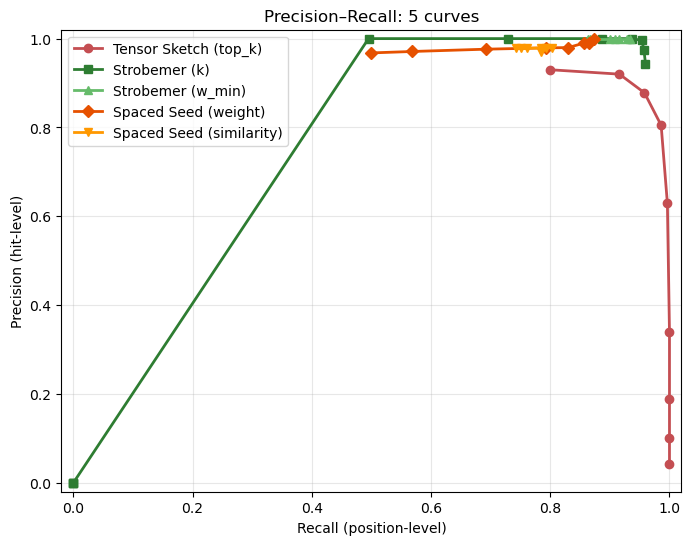

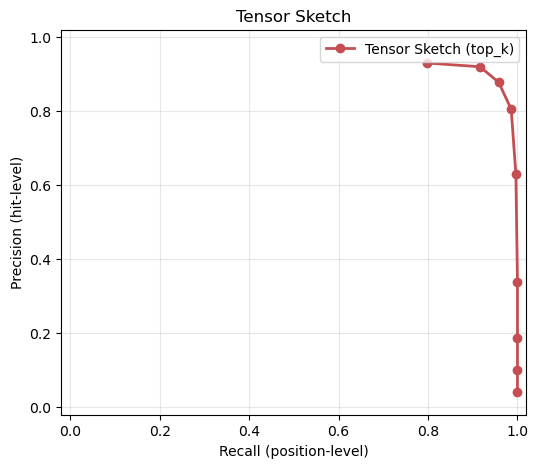

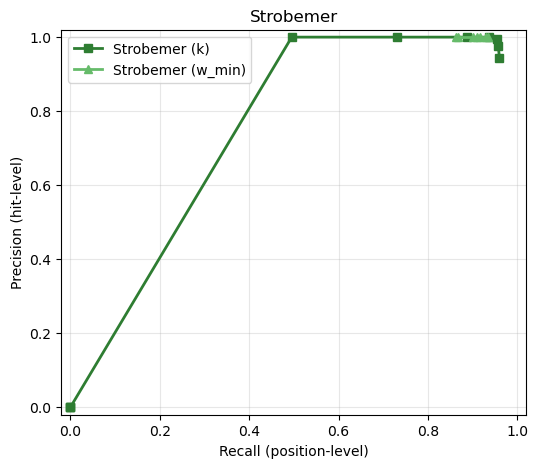

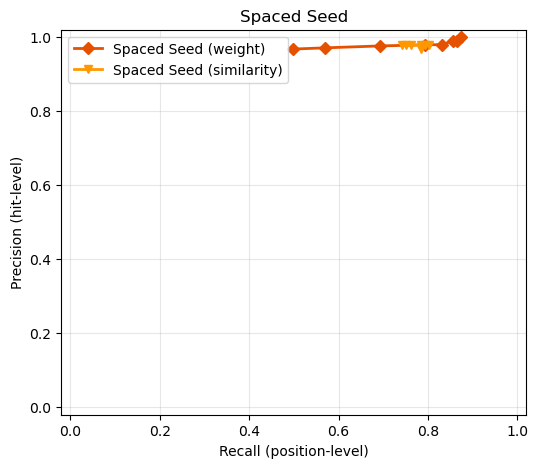

Saved: /home/luting/projects/AnchorMapping/NavigaMer/methods/v4_benchmark_output/pr_plot_data.json


In [9]:
# ── Plot: main (5 curves) + 3 method subplots; save pr_plot_data.json ──
CURVE_COLORS = {"ts_top_k": "#C44E52", "strobemer_k": "#2E7D32", "strobemer_w_min": "#66BB6A", "spaced_weight": "#E65100", "spaced_similarity": "#FF9800"}
CURVE_MARKERS = {"ts_top_k": "o", "strobemer_k": "s", "strobemer_w_min": "^", "spaced_weight": "D", "spaced_similarity": "v"}
curve_labels = {s["curve_id"]: s["label"] for s in CURVE_SPECS}
fig_main, ax_main = plt.subplots(figsize=(8, 6))
for spec in CURVE_SPECS:
    cid, pts = spec["curve_id"], curve_series.get(spec["curve_id"], [])
    if not pts:
        continue
    ax_main.plot([p["recall"] for p in pts], [p["precision"] for p in pts], marker=CURVE_MARKERS.get(cid, "o"), label=curve_labels[cid], color=CURVE_COLORS.get(cid), linewidth=2, markersize=6)
ax_main.set_xlabel("Recall (position-level)")
ax_main.set_ylabel("Precision (hit-level)")
ax_main.set_title("Precision–Recall: 5 curves")
ax_main.legend()
ax_main.grid(True, alpha=0.3)
ax_main.set_xlim(-0.02, 1.02)
ax_main.set_ylim(-0.02, 1.02)
fig_main.savefig(OUTPUT_DIR / "pr_tradeoff_main.png", bbox_inches="tight", dpi=150)
plt.show()
method_to_curves = {"tensor_sketch": ["ts_top_k"], "strobemer": ["strobemer_k", "strobemer_w_min"], "spaced_seed": ["spaced_weight", "spaced_similarity"]}
method_titles = {"tensor_sketch": "Tensor Sketch", "strobemer": "Strobemer", "spaced_seed": "Spaced Seed"}
for method, cids in method_to_curves.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    for cid in cids:
        pts = curve_series.get(cid, [])
        if not pts:
            continue
        ax.plot([p["recall"] for p in pts], [p["precision"] for p in pts], marker=CURVE_MARKERS.get(cid, "o"), label=curve_labels[cid], color=CURVE_COLORS.get(cid), linewidth=2, markersize=6)
    ax.set_xlabel("Recall (position-level)")
    ax.set_ylabel("Precision (hit-level)")
    ax.set_title(method_titles[method])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    fig.savefig(OUTPUT_DIR / f"pr_tradeoff_{method}.png", bbox_inches="tight", dpi=150)
    plt.show()
main_plot_series = [{"curve_id": s["curve_id"], "label": curve_labels[s["curve_id"]], "x": [p["recall"] for p in curve_series.get(s["curve_id"], [])], "y": [p["precision"] for p in curve_series.get(s["curve_id"], [])], "color": CURVE_COLORS.get(s["curve_id"]), "marker": CURVE_MARKERS.get(s["curve_id"], "o")} for s in CURVE_SPECS]
method_subplots = {m: [{"curve_id": cid, "label": curve_labels[cid], "x": [p["recall"] for p in curve_series.get(cid, [])], "y": [p["precision"] for p in curve_series.get(cid, [])], "color": CURVE_COLORS.get(cid), "marker": CURVE_MARKERS.get(cid, "o")} for cid in cids] for m, cids in method_to_curves.items()}
with open(OUTPUT_DIR / "pr_plot_data.json", "w") as f:
    json.dump({"main_plot_series": main_plot_series, "method_subplots": method_subplots, "style_meta": {"sort_order": "recall_asc", "curve_colors": CURVE_COLORS, "curve_markers": CURVE_MARKERS}}, f, indent=2, default=json_serial)
print("Saved:", OUTPUT_DIR / "pr_plot_data.json")

In [10]:
# ── Summary: per-curve cost (dPrec/dRec) ──
def summarize_pr_tradeoff(curve_series, curve_labels):
    lines = []
    for cid, pts in curve_series.items():
        label = curve_labels.get(cid, cid)
        if len(pts) < 2:
            lines.append(f"{label}: insufficient points")
            continue
        p0, p1 = pts[0], pts[-1]
        recall_gain = p1["recall"] - p0["recall"]
        prec_drop = p0["precision"] - p1["precision"]
        if recall_gain > 1e-6:
            cost = prec_drop / recall_gain
            lines.append(f"{label}: recall {p0['recall']:.3f}->{p1['recall']:.3f}, precision {p0['precision']:.3f}->{p1['precision']:.3f}; cost (dPrec/dRec) ≈ {cost:.3f}")
        else:
            lines.append(f"{label}: recall ~{p0['recall']:.3f}, precision ~{p0['precision']:.3f}")
    return "\n".join(lines)
print(summarize_pr_tradeoff(curve_series, curve_labels))

Tensor Sketch (top_k): recall 0.799->1.000, precision 0.930->0.042; cost (dPrec/dRec) ≈ 4.412
Strobemer (k): recall 0.000->0.960, precision 0.000->0.943; cost (dPrec/dRec) ≈ -0.983
Strobemer (w_min): recall 0.864->0.934, precision 1.000->1.000; cost (dPrec/dRec) ≈ 0.000
Spaced Seed (weight): recall 0.499->0.874, precision 0.968->1.000; cost (dPrec/dRec) ≈ -0.086
Spaced Seed (similarity): recall 0.742->0.803, precision 0.978->0.979; cost (dPrec/dRec) ≈ -0.026
